# Predicción de Ingresos Totales del Canal de Panamá
## Modelo: Random Forest

## ¿Qué es Random Forest?

Random Forest es un algoritmo de **ensemble learning** que combina múltiples árboles de decisión para mejorar la precisión y reducir el overfitting.

### Principios fundamentales:

1. **Bagging (Bootstrap Aggregating)**: Cada árbol se entrena con un subconjunto aleatorio de los datos de entrenamiento (con reemplazo). Esto significa que cada árbol ve una muestra diferente del conjunto total.

2. **Subconjuntos aleatorios de features**: En cada división del árbol, solo se considera un subconjunto aleatorio de las variables predictoras. Esto evita que todos los árboles se enfocalicen en las mismas features dominantes.

3. **Agregación de predicciones**: La predicción final es el **promedio** de las predicciones de todos los árboles individuales (para regresión).

### Hiperparámetros clave:
- `n_estimators`: Número de árboles en el bosque
- `max_depth`: Profundidad máxima de cada árbol
- `max_features`: Número de features consideradas por cada división
- `min_samples_split`: Mínimo de muestras para dividir un nodo

### Ventajas:
- Robustez y menor sobreajuste que un solo árbol
- Maneja relaciones no lineales
- Proporciona importancia de features
- Poco requiere de escalado de datos

### Limitaciones:
- Menor interpretabilidad que un árbol individual
- Mayor consumo de memoria y tiempo computacional
- Puede ser menos preciso que modelos más complejos (boosting)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

Matplotlib is building the font cache; this may take a moment.


## 1. Carga y Preparación de Datos

In [2]:
df = pd.read_csv("A07607236202602121443442025_transporte_acp.csv", encoding='latin-1')

df = df.rename(columns={
    "Ingresos por Peaje Panamax": "Ingresos Panamax",
    "Ingresos por Peaje NeoPanamax": "Ingresos NeoPanamax",
    "Tonelada Netas Neopanamax": "Toneladas Netas NeoPanamax"
})

df["Ingresos Totales"] = df["Ingresos Panamax"] + df["Ingresos NeoPanamax"]
df["Total Transitos"] = (
    df["Transito de Naves Alto Calado Panamax"]
    + df["Transito de Naves Pequeño Calado Panamax"]
    + df["Transito de Naves NeoPanamax"]
)
df["Total Toneladas"] = df["Toneladas Netas Panamax"] + df["Toneladas Netas NeoPanamax"]
df["Total Volumen"] = df["Volumen de Carga Panamax"] + df["Volumen de Carga NeoPanamax"]

meses = {
    "Enero": 1, "Febrero": 2, "Marzo": 3, "Abril": 4,
    "Mayo": 5, "Junio": 6, "Julio": 7, "Agosto": 8,
    "Septiembre": 9, "Octubre": 10, "Noviembre": 11, "Diciembre": 12
}
df["Num_Mes"] = df["Mes"].map(meses)
df["Mes_Indice"] = range(len(df))

print(f"Dimensiones del dataset: {df.shape}")
df.head()

Dimensiones del dataset: (72, 17)


,Año,Mes,Transito de Naves Alto Calado Panamax,Transito de Naves Pequeño Calado Panamax,Ingresos Panamax,Toneladas Netas Panamax,Volumen de Carga Panamax,Transito de Naves NeoPanamax,Ingresos NeoPanamax,Toneladas Netas NeoPanamax,Volumen de Carga NeoPanamax,Ingresos Totales,Total Transitos,Total Toneladas,Total Volumen,Num_Mes,Mes_Indice
0,2020,Enero,826,149,110198056,21167387,13324583,308,135551279,23811798,9311252,245749335,1283,44979185,22635835,1,0
1,2020,Febrero,753,206,100158695,19293825,13054336,268,112186169,19811487,8662008,212344864,1227,39105312,21716344,2,1
2,2020,Marzo,825,124,110757041,21512145,15397768,261,105134233,19232310,7836721,215891274,1210,40744455,23234489,3,2
3,2020,Abril,698,53,96144271,17615626,13232901,271,121704852,19898460,9636220,217849123,1022,37514086,22869121,4,3
4,2020,Mayo,640,43,85960793,15530225,12631808,254,115570390,18800359,7521629,201531183,937,34330584,20153437,5,4


## 2. Selección de Features y División de Datos

In [3]:
features = [
    "Transito de Naves Alto Calado Panamax",
    "Transito de Naves Pequeño Calado Panamax",
    "Toneladas Netas Panamax",
    "Volumen de Carga Panamax",
    "Transito de Naves NeoPanamax",
    "Toneladas Netas NeoPanamax",
    "Volumen de Carga NeoPanamax",
    "Total Transitos",
    "Total Toneladas",
    "Total Volumen",
    "Num_Mes",
    "Mes_Indice"
]

target = "Ingresos Totales"

train = df[df["Año"] < 2025]
val = df[df["Año"] == 2025]

X_train = train[features]
y_train = train[target]
X_val = val[features]
y_val = val[target]

print(f"Datos de entrenamiento: {X_train.shape[0]} registros (2020-2024)")
print(f"Datos de validación:    {X_val.shape[0]} registros (2025)")

Datos de entrenamiento: 60 registros (2020-2024)
Datos de validación:    12 registros (2025)


## 3. Búsqueda de Hiperparámetros (n_estimators)

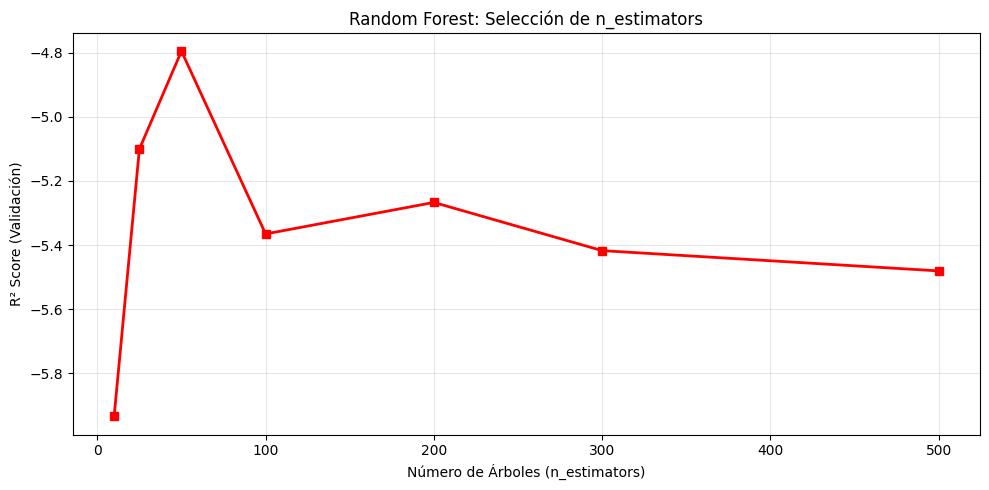

Mejor n_estimators: 50 (R² = -4.7955)


In [4]:
n_trees = [10, 25, 50, 100, 200, 300, 500]
val_scores = []

for n in n_trees:
    rf = RandomForestRegressor(n_estimators=n, max_depth=10, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    val_scores.append(rf.score(X_val, y_val))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_trees, val_scores, 'r-s', linewidth=2)
ax.set_xlabel('Número de Árboles (n_estimators)')
ax.set_ylabel('R² Score (Validación)')
ax.set_title('Random Forest: Selección de n_estimators')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_n = n_trees[np.argmax(val_scores)]
print(f"Mejor n_estimators: {best_n} (R² = {max(val_scores):.4f})")

## 4. Entrenamiento del Modelo

In [5]:
model = RandomForestRegressor(n_estimators=best_n, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
y_pred_val = model.predict(X_val)

print(f"Modelo entrenado con {model.n_estimators} árboles")

Modelo entrenado con 50 árboles


## 5. Evaluación del Modelo

In [6]:
rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
mae = mean_absolute_error(y_val, y_pred_val)
r2 = r2_score(y_val, y_pred_val)

print(f"=== Métricas de Evaluación (Validación 2025) ===")
print(f"RMSE:  ${rmse:,.0f}")
print(f"MAE:   ${mae:,.0f}")
print(f"R²:    {r2:.4f}")

=== Métricas de Evaluación (Validación 2025) ===
RMSE:  $33,058,468
MAE:   $32,070,264
R²:    -4.7955


## 6. Visualización: Reales vs Predichos (2025)

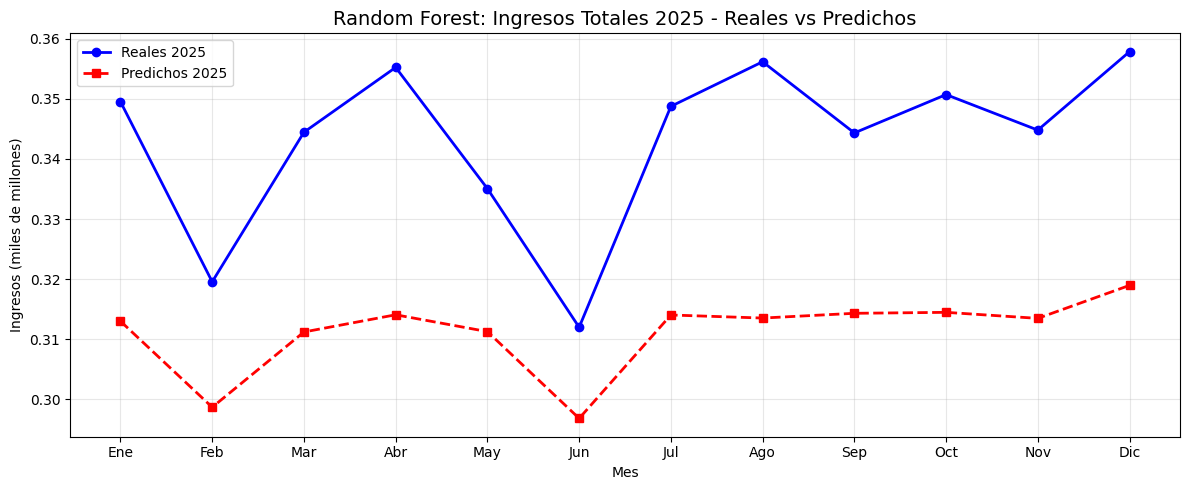

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
x_axis = range(1, 13)
meses_labels = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

ax.plot(x_axis, y_val.values / 1e9, 'b-o', label='Reales 2025', linewidth=2)
ax.plot(x_axis, y_pred_val / 1e9, 'r--s', label='Predichos 2025', linewidth=2)
ax.set_xticks(x_axis)
ax.set_xticklabels(meses_labels)
ax.set_title('Random Forest: Ingresos Totales 2025 - Reales vs Predichos', fontsize=14)
ax.set_xlabel('Mes')
ax.set_ylabel('Ingresos (miles de millones)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Importancia de Features

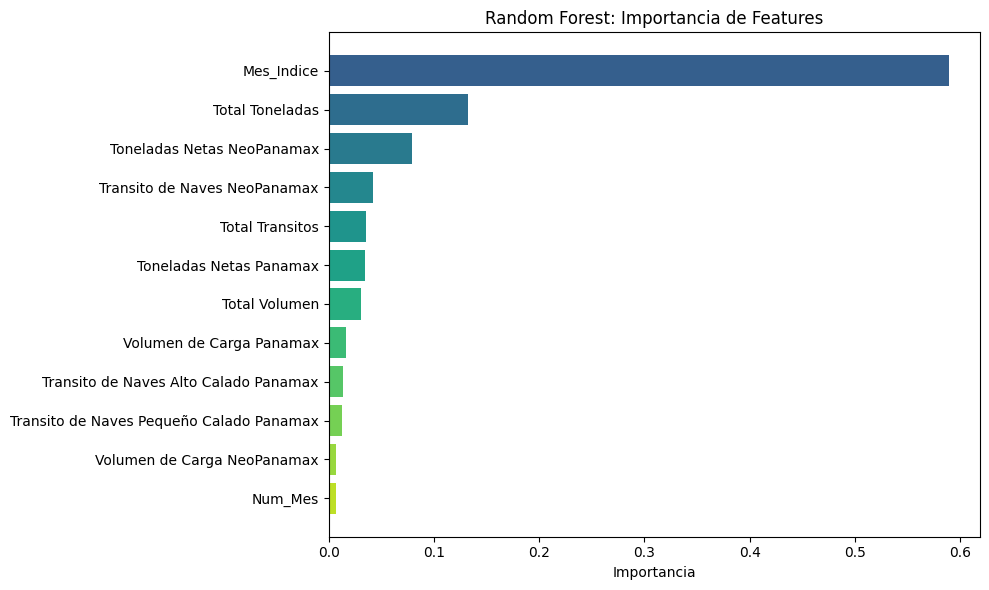


Top 5 features más importantes:
                     Feature  Importancia
                  Mes_Indice     0.589356
             Total Toneladas     0.132110
  Toneladas Netas NeoPanamax     0.079027
Transito de Naves NeoPanamax     0.042060
             Total Transitos     0.035173


In [8]:
importance = pd.DataFrame({
    "Feature": features,
    "Importancia": model.feature_importances_
}).sort_values("Importancia", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(importance)))
ax.barh(importance["Feature"], importance["Importancia"], color=colors)
ax.set_xlabel('Importancia')
ax.set_title('Random Forest: Importancia de Features')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 5 features más importantes:")
print(importance.head().to_string(index=False))

## 8. Predicción de Ingresos Totales 2026

In [9]:
meses_nombre = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
                "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]

predict_2026 = pd.DataFrame()
for i, mes in enumerate(meses_nombre):
    row = {
        "Año": 2026,
        "Mes": mes,
        "Num_Mes": i + 1,
        "Mes_Indice": 72 + i,
    }
    month_avg = df[df["Mes"] == mes][features[:-2]].mean()
    for feat in features[:-2]:
        row[feat] = month_avg[feat]
    predict_2026 = pd.concat([predict_2026, pd.DataFrame([row])], ignore_index=True)

X_2026 = predict_2026[features]
predicciones_2026 = model.predict(X_2026)
predict_2026["Ingresos Totales Predichos"] = predicciones_2026

print("=== Predicción de Ingresos Totales 2026 ===")
for _, row in predict_2026.iterrows():
    print(f"{row['Mes']:12s}: ${row['Ingresos Totales Predichos']:>18,.0f}")

total_2026 = predict_2026["Ingresos Totales Predichos"].sum()
print(f"\n{'Total 2026':12s}: ${total_2026:>18,.0f}")

=== Predicción de Ingresos Totales 2026 ===
Enero       : $       314,519,580
Febrero     : $       296,484,898
Marzo       : $       308,957,052
Abril       : $       306,802,561
Mayo        : $       307,883,859
Junio       : $       299,504,539
Julio       : $       311,165,724
Agosto      : $       313,944,793
Septiembre  : $       309,088,388
Octubre     : $       315,437,705
Noviembre   : $       312,151,612
Diciembre   : $       317,784,196

Total 2026  : $     3,713,724,908


## 9. Visualización de Tendencia Histórica y Predicción 2026

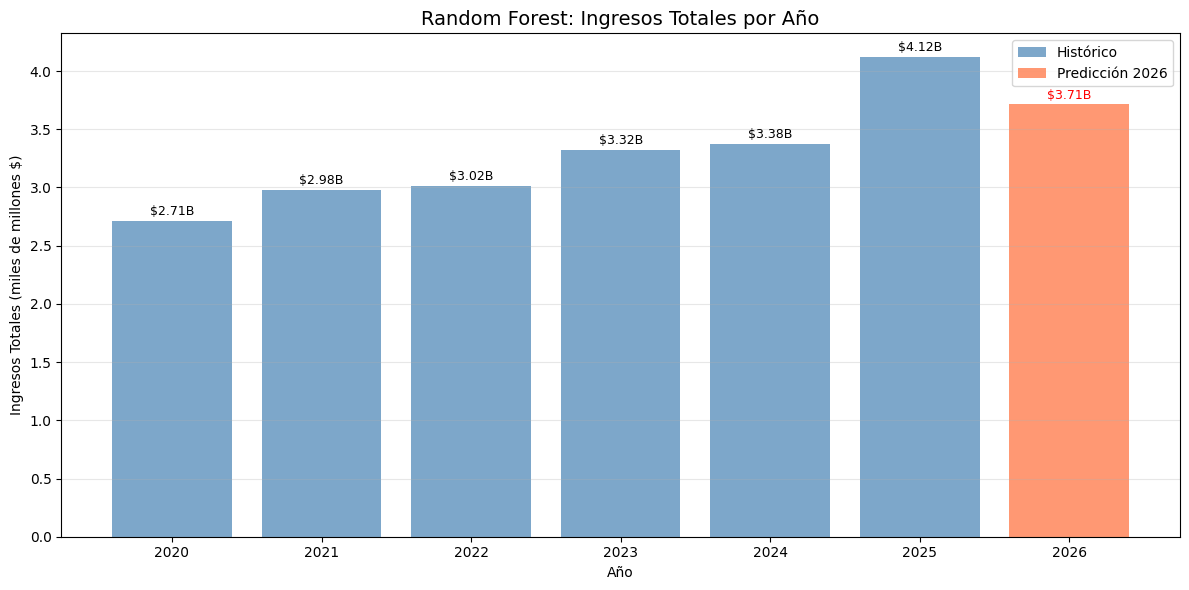

In [10]:
ingresos_anuales = df.groupby("Año")["Ingresos Totales"].sum()

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(ingresos_anuales.index.astype(str), ingresos_anuales.values / 1e9, 
       color='steelblue', alpha=0.7, label='Histórico')
ax.bar("2026", total_2026 / 1e9, color='coral', alpha=0.8, label='Predicción 2026')

for i, (year, val) in enumerate(ingresos_anuales.items()):
    ax.text(i, val / 1e9 + 0.05, f'${val/1e9:.2f}B', ha='center', fontsize=9)
ax.text(len(ingresos_anuales), total_2026 / 1e9 + 0.05, f'${total_2026/1e9:.2f}B', 
        ha='center', fontsize=9, color='red')

ax.set_title('Random Forest: Ingresos Totales por Año', fontsize=14)
ax.set_xlabel('Año')
ax.set_ylabel('Ingresos Totales (miles de millones $)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
predict_2026[["Año", "Mes", "Ingresos Totales Predichos"]].to_csv("prediccion_2026.csv", index=False)
print("Predicciones exportadas a prediccion_2026.csv")

Predicciones exportadas a prediccion_2026.csv


## Conclusiones
- Random Forest combina múltiples árboles de decisión para reducir la varianza y mejorar la generalización.
- Cada árbol se entrena con un subconjunto aleatorio de datos (bagging) y features, promediando sus predicciones.
- La importancia de features revela qué variables tienen mayor impacto en los ingresos.
- Ventaja principal: robustez frente a overfitting comparado con un solo árbol.
- Limitación: menor interpretabilidad que un árbol individual.